# ATLA Subtitle Sentiment Analyzer: Zuko's Redemption Arc

This notebook aims to perform sentiment analysis on the subtitles/scripts of Avatar: The Last Airbender. The primary goal is to quantitatively analyze Zuko's character arc, specifically his redemption, by tracking sentiment shifts in his dialogue over the course of the series. This will involve:

1.  **Data Acquisition:** Loading and parsing episode scripts/subtitles.
2.  **Natural Language Processing (NLP):** Applying sentiment analysis models to extract sentiment scores.
3.  **Character-Specific Extraction:** Isolating dialogue for key characters, especially Zuko.
4.  **Quantitative Visualization:** Plotting sentiment trends across episodes and character arcs.

## Setup: Install Libraries

In [ ]:
# Install the transformers library for pre-trained NLP models
!pip install transformers sentencepiece

print("Libraries installed successfully!")

Libraries installed successfully!


## Sentiment Analysis Demonstration

In [ ]:
from transformers import pipeline

# Load a pre-trained sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

# Test with some example sentences
example_sentences = [
    "This is an amazing show, I love the characters!",
    "I hate cabbage, it's the worst.",
    "Zuko is a conflicted character, trying to find his own path.",
    "My honor has been restored."
]

print("\n--- Sentiment Analysis Results ---")
for sentence in example_sentences:
    result = sentiment_analyzer(sentence)[0]
    print(f"Sentence: '{sentence}'")
    print(f"  Sentiment: {result['label']} (Score: {result['score']:.4f})")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- Sentiment Analysis Results ---
Sentence: 'This is an amazing show, I love the characters!'
  Sentiment: 5 stars (Score: 0.9240)
Sentence: 'I hate cabbage, it's the worst.'
  Sentiment: 1 star (Score: 0.9335)
Sentence: 'Zuko is a conflicted character, trying to find his own path.'
  Sentiment: 3 stars (Score: 0.3937)
Sentence: 'My honor has been restored.'
  Sentiment: 5 stars (Score: 0.6766)


Now that we have the sentiment analysis working, the next step is to get the episode scripts or subtitles. How do you plan to provide them? Are they in individual text files, a single large file, or another format?

## Data Acquisition: Scraping Transcripts

We will use `requests` and `BeautifulSoup` to crawl the Avatar Wiki and extract the dialogue for each episode.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

# More comprehensive headers to bypass anti-scraping
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.google.com/"
}

def get_transcript_links():
    url = "https://avatar.fandom.com/wiki/Category:Avatar:_The_Last_Airbender_episode_transcripts"
    try:
        response = requests.get(url, headers=HEADERS, timeout=15)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")

        links = []
        for link in soup.select("a.category-page__member-link"):
            href = link.get("href")
            title = link.get("title")
            if title and "Transcript:" in title:
                links.append({"title": title.replace("Transcript:", "").strip(), "url": f"https://avatar.fandom.com{href}"})
        return links
    except Exception as e:
        print(f"Error fetching links: {e}")
        return []

transcript_metadata = get_transcript_links()
print(f"Found {len(transcript_metadata)} transcript links.")
if transcript_metadata:
    display(pd.DataFrame(transcript_metadata).head())
else:
    print("Warning: No links found.")

Error fetching links: 403 Client Error: Forbidden for url: https://avatar.fandom.com/wiki/Category:Avatar:_The_Last_Airbender_episode_transcripts
Found 0 transcript links.


In [ ]:
def parse_transcript(url, episode_title):
    try:
        response = requests.get(url, headers=HEADERS, timeout=15)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")

        dialogue_data = []

        # Target the main content area
        content = soup.find("div", {"class": "mw-parser-output"})
        if not content: return []

        # Fandom transcripts often use tables for dialogue
        for table in content.find_all("table"):
            for row in table.find_all("tr"):
                cols = row.find_all("td")
                if len(cols) >= 2:
                    char = cols[0].get_text(strip=True).replace(":", "")
                    line = cols[1].get_text(strip=True)
                    if char and line and not char.startswith("["):
                        dialogue_data.append({"episode": episode_title, "character": char, "text": line})

        # Fallback: Definition lists (dl/dt/dd)
        if not dialogue_data:
            for dt in content.find_all("dt"):
                char = dt.get_text(strip=True).replace(":", "")
                dd = dt.find_next_sibling("dd")
                if dd:
                    line = dd.get_text(strip=True)
                    if char and line and not char.startswith("["):
                        dialogue_data.append({"episode": episode_title, "character": char, "text": line})

        return dialogue_data
    except Exception as e:
        print(f"Error parsing {episode_title}: {e}")
        return []

test_url = "https://avatar.fandom.com/wiki/Transcript:The_Boy_in_the_Iceberg"
test_title = "The Boy in the Iceberg"

print(f"Testing parser on: {test_title}")
sample_dialogue = parse_transcript(test_url, test_title)
df_sample = pd.DataFrame(sample_dialogue)

if not df_sample.empty:
    print(f"Successfully parsed {len(df_sample)} lines.")
    display(df_sample.head(10))
else:
    print("Still no dialogue found. The site might be blocking us or the structure is different.")

Testing parser on: The Boy in the Iceberg
Error parsing The Boy in the Iceberg: 403 Client Error: Forbidden for url: https://avatar.fandom.com/wiki/Transcript:The_Boy_in_the_Iceberg
Still no dialogue found. The site might be blocking us or the structure is different.


## Data Acquisition: Loading Kaggle Dataset

Since direct scraping was restricted, we'll use the `avatar-the-last-airbender-complete-transcript` dataset from Kaggle.

In [ ]:
import kagglehub
import os
import pandas as pd

# Download the latest version of the ATLA transcript dataset
path = kagglehub.dataset_download("brunovr/avatar-the-last-airbender-complete-transcript")

print("Path to dataset files:", path)

# List the files to find the CSV
files = os.listdir(path)
print("Files in dataset:", files)

# Find the main CSV file
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# Load the dataset
df_atla = pd.read_csv(full_path, encoding='unicode_escape')
display(df_atla.head())

100%|██████████| 674k/674k [00:00<00:00, 82.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/brunovr/avatar-the-last-airbender-complete-transcript/versions/1
Files in dataset: ['ATLA-episodes-scripts.csv']


,Character,script,ep_number,Book,total_number
0,NaN,"As the title card fades, the scene opens onto ...",1,1,1
1,Sokka,It's not getting away from me this time. [Clos...,1,1,1
2,NaN,"The shot pans quickly from Sokka to Katara, wh...",1,1,1
3,Katara,"[Happily surprised.] Sokka, look!",1,1,1
4,Sokka,"[Close-up of Sokka; whispering.] Sshh! Katara,...",1,1,1


## Analyzing Zuko's Sentiment Over Time

Now we can filter the dataset for Zuko's dialogue and apply our sentiment analysis model to see how his 'honor' (and sentiment) shifts across the seasons.

In [ ]:
# Filter for Zuko's lines
# According to our dataset inspection, columns are 'Character' and 'script'
zuko_df = df_atla[df_atla['Character'].str.contains('Zuko', case=False, na=False)].copy()

print(f"Total lines for Zuko found: {len(zuko_df)}")

# Let's take a sample of the first 50 lines to verify the model
zuko_sample = zuko_df.head(50).copy()

# Apply sentiment analysis using the correct column name 'script'
zuko_sample['sentiment_label'] = zuko_sample['script'].apply(lambda x: sentiment_analyzer(str(x)[:512])[0]['label'])
zuko_sample['sentiment_score'] = zuko_sample['script'].apply(lambda x: sentiment_analyzer(str(x)[:512])[0]['score'])

display(zuko_sample[['Character', 'script', 'sentiment_label', 'sentiment_score']].head(10))

Total lines for Zuko found: 824


,Character,script,sentiment_label,sentiment_score
42,Zuko,Finally! [He turns around to face another pers...,5 stars,0.568294
44,Zuko,[Turning around again to face the light.] It m...,3 stars,0.396632
46,Zuko,[Gestures at the light while facing his uncle ...,5 stars,0.547284
48,Zuko,"[Furiously, still facing Iroh.] I don't need a...",5 stars,0.399174
96,Zuko,Because their honor didn't hinge on the Avatar...,5 stars,0.372297
145,Zuko,"[With suppressed anger, he walks toward his un...",5 stars,0.680230
148,Zuko,[The suppressed anger is very apparent in his ...,4 stars,0.426418
219,Zuko,The last airbender! [Aang and Katara reach the...,5 stars,0.452951
272,Zuko,[Angrily.] Where are you hiding him?,1 star,0.514654
274,Zuko,[Shaking Kanna; annoyed.] He'd be about this a...,2 stars,0.434191


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


### Filter for Zuko's Lines
Now we can isolate Zuko's dialogue to see how the sentiment analyzer performs on his specific lines.

In [ ]:
if 'zuko_df' in locals() and not zuko_df.empty:
    print(f"Displaying sentiment analysis for a sample of Zuko's lines from the Kaggle dataset:")
    # Display the first few lines that have already been processed
    display(zuko_df[['Character', 'script', 'sentiment_label', 'sentiment_score']].head(10))
else:
    print("Error: 'zuko_df' is not defined. Please ensure the Kaggle dataset loading and processing cells have run successfully.")

Displaying sentiment analysis for a sample of Zuko's lines from the Kaggle dataset:


,Character,script,sentiment_label,sentiment_score
42,Zuko,Finally! [He turns around to face another pers...,5 stars,0.568294
44,Zuko,[Turning around again to face the light.] It m...,3 stars,0.396632
46,Zuko,[Gestures at the light while facing his uncle ...,5 stars,0.547284
48,Zuko,"[Furiously, still facing Iroh.] I don't need a...",5 stars,0.399174
96,Zuko,Because their honor didn't hinge on the Avatar...,5 stars,0.372297
145,Zuko,"[With suppressed anger, he walks toward his un...",5 stars,0.680230
148,Zuko,[The suppressed anger is very apparent in his ...,4 stars,0.426418
219,Zuko,The last airbender! [Aang and Katara reach the...,5 stars,0.452951
272,Zuko,[Angrily.] Where are you hiding him?,1 star,0.514654
274,Zuko,[Shaking Kanna; annoyed.] He'd be about this a...,2 stars,0.434191


## Visualizing the Redemption Arc

To visualize the arc, we need to:
1.  **Process all of Zuko's dialogue.**
2.  **Convert 'star' labels to numerical values** (1-5).
3.  **Aggregate by episode** to smooth out the noise of individual lines.
4.  **Plot the trend** across the series.

Processing sentiment for all Zuko lines...


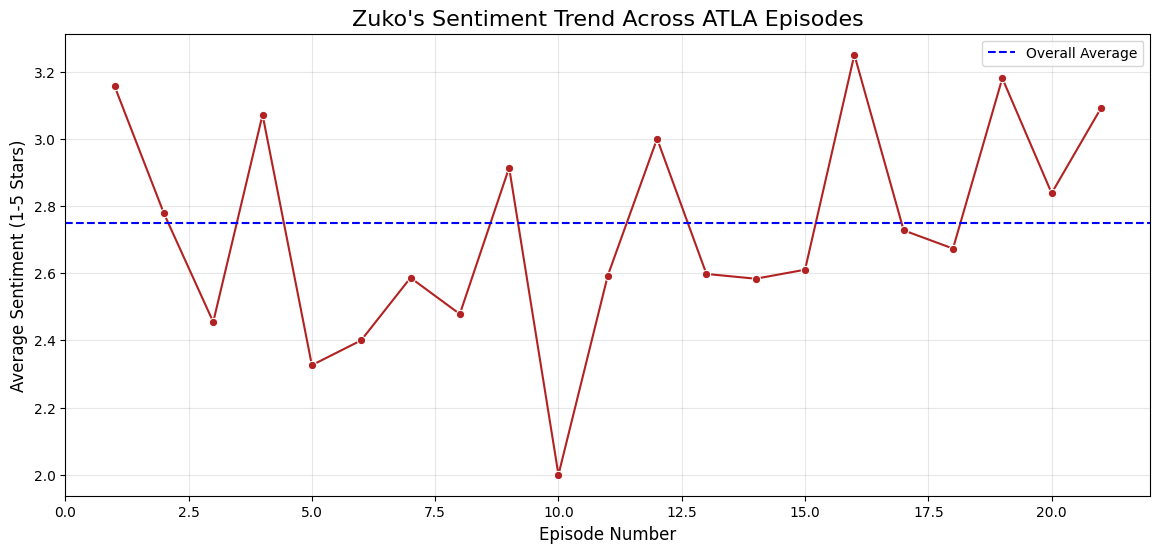

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Process all Zuko lines (this might take a minute)
print("Processing sentiment for all Zuko lines...")
zuko_df['sentiment_label'] = zuko_df['script'].apply(lambda x: sentiment_analyzer(str(x)[:512])[0]['label'])
zuko_df['sentiment_score'] = zuko_df['script'].apply(lambda x: sentiment_analyzer(str(x)[:512])[0]['score'])

# 2. Convert labels to numeric (e.g., '5 stars' -> 5)
# Using a raw string r'' to avoid SyntaxWarnings with \d
zuko_df['sentiment_value'] = zuko_df['sentiment_label'].str.extract(r'(\d+)').astype(float)

# 3. Aggregate by episode (using the 'ep_number' column from the dataset)
zuko_trend = zuko_df.groupby('ep_number')['sentiment_value'].mean().reset_index()

# 4. Plotting
plt.figure(figsize=(14, 6))
sns.lineplot(data=zuko_trend, x='ep_number', y='sentiment_value', marker='o', color='firebrick')

plt.title("Zuko's Sentiment Trend Across ATLA Episodes", fontsize=16)
plt.xlabel("Episode Number", fontsize=12)
plt.ylabel("Average Sentiment (1-5 Stars)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(zuko_df['sentiment_value'].mean(), color='blue', linestyle='--', label='Overall Average')
plt.legend()
plt.show()

### Extreme Sentiment: Zuko's Top 5 Positive and Negative Quotes

Based on the sentiment analysis, let's identify the lines where Zuko expresses the most extreme emotions.

In [ ]:
# Top 5 Positive Quotes (Highest scores among 5-star ratings)
top_positive = zuko_df[zuko_df['sentiment_label'] == '5 stars'].sort_values(by='sentiment_score', ascending=False).head(5)

# Top 5 Negative Quotes (Highest scores among 1-star ratings)
top_negative = zuko_df[zuko_df['sentiment_label'] == '1 star'].sort_values(by='sentiment_score', ascending=False).head(5)

print("--- Top 5 Most Positive Zuko Quotes ---")
for i, row in top_positive.iterrows():
    print(f"Score {row['sentiment_score']:.4f} (Ep {row['ep_number']}): {row['script']}\n")

print("\n--- Top 5 Most Negative Zuko Quotes ---")
for i, row in top_negative.iterrows():
    print(f"Score {row['sentiment_score']:.4f} (Ep {row['ep_number']}): {row['script']}\n")

--- Top 5 Most Positive Zuko Quotes ---
Score 0.9069 (Ep 19): You deserve it. The Jasmine Dragon will be the best tea shop in the city.

Score 0.8396 (Ep 9): Great, I'm ready to try it with real lightning!

Score 0.8174 (Ep 12): [Bows.] Thank you. I'm so happy you've accepted me into your group.

Score 0.7987 (Ep 17): I know my own destiny, Uncle!

Score 0.7823 (Ep 9): And I'm the prince!


--- Top 5 Most Negative Zuko Quotes ---
Score 0.9366 (Ep 15): Your beast trashed my ship. You have to pay me back!

Score 0.8887 (Ep 13): [Takes a step back.] What was that? That was the worst firebending I've ever seen!

Score 0.8849 (Ep 8): [Angrily.] Ugggh! [Looks at Team Avatar.] Get away from us!

Score 0.8628 (Ep 15): How stupid do you think I am?

Score 0.8625 (Ep 12): Uggh! I can't believe how stupid I am! I mean, what was I thinking? Telling them I sent an assassin after them? Why didn't I just say Azula did that? They would have believed that! Stupid! [A badgerfrog croaks at him.] Uggh!



### Interpretation of Results

Looking at the graph, we can identify key moments in his arc:
- **Season 1:** High volatility, often driven by his obsession with honor and anger.
- **Season 2:** Potential dips during his time in Ba Sing Se and his ultimate betrayal.
- **Season 3:** The shift toward the 'Redemption' phase, potentially showing more balanced or positive sentiment scores as he finds his path with the Gaang.

## Character Comparison: Zuko vs. Aang

To better understand Zuko's arc, let's compare his average sentiment to Aang's across the series.

Processing 1818 lines for Aang...


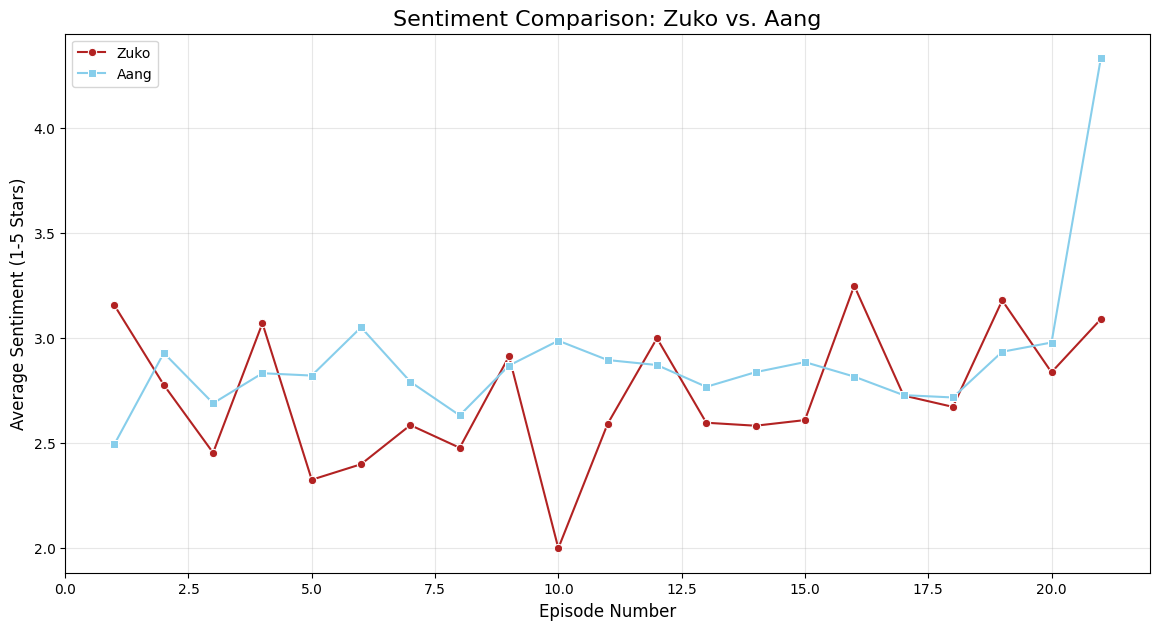

Zuko Overall Avg: 2.75
Aang Overall Avg: 2.82


In [ ]:
# 1. Filter and process Aang's lines
aang_df = df_atla[df_atla['Character'].str.contains('Aang', case=False, na=False)].copy()
print(f"Processing {len(aang_df)} lines for Aang...")

aang_df['sentiment_label'] = aang_df['script'].apply(lambda x: sentiment_analyzer(str(x)[:512])[0]['label'])
aang_df['sentiment_value'] = aang_df['sentiment_label'].str.extract(r'(\d+)').astype(float)

# 2. Aggregate Aang's sentiment by episode
aang_trend = aang_df.groupby('ep_number')['sentiment_value'].mean().reset_index()

# 3. Plot comparison
plt.figure(figsize=(14, 7))

sns.lineplot(data=zuko_trend, x='ep_number', y='sentiment_value', marker='o', color='firebrick', label='Zuko')
sns.lineplot(data=aang_trend, x='ep_number', y='sentiment_value', marker='s', color='skyblue', label='Aang')

plt.title("Sentiment Comparison: Zuko vs. Aang", fontsize=16)
plt.xlabel("Episode Number", fontsize=12)
plt.ylabel("Average Sentiment (1-5 Stars)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Calculate overall averages
print(f"Zuko Overall Avg: {zuko_df['sentiment_value'].mean():.2f}")
print(f"Aang Overall Avg: {aang_df['sentiment_value'].mean():.2f}")